### Columns Over view

The dataset contains the records of financial transactions for fraud detection. (6.3 Million Records)
Some of these records were flagged false by existing algorithms.

Further approaches could be used to feature engineer properties that could further strengthen the fraud detection algorithms as well as find out where the existing algorithm lacks.

CASH-IN: is the process of increasing the balance of
account by paying in cash to a merchant.

CASH-OUT: is the opposite process of CASH-IN, it
means to withdraw cash from a merchant which decreases
the balance of the account.

DEBIT: is similar process than CASH-OUT and involves sending the money from the mobile money service
to a bank account.

PAYMENT: is the process of paying for goods or services to merchants which decreases the balance of the account and increases the balance of the receiver.

TRANSFER: is the process of sending money to another user of the service through the mobile money platform

step: 
Step denotes a portion of the time period

type:
Type of the transaction

amount:
Amount involved in transaction

nameOrig:
Name of the source account

oldbalanceOrg:
Old balance of source account

newbalanceOrig:
New balance of source account

nameDest:
Name of the target account

oldbalanceDest:
Old balance of target account

newbalanceDest:
New balance of target account

isFraud:
1 means is Fraud 0 means its not

isFlaggedFraud:
Was the system able to detect if the transaction is fraud or not based on existing techniques

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [7]:
df = pd.read_csv('AIML Dataset.csv')

In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

This denotes that 8,213 transactions are fraud

In [10]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
#checking for null values
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [16]:
df.shape

(6362620, 11)

In [27]:
# fraud%

#  (# of fraud records / total # of rows )* 100
print(round((df['isFraud'].value_counts()[1] / df.shape [0]) *100,2))

0.13


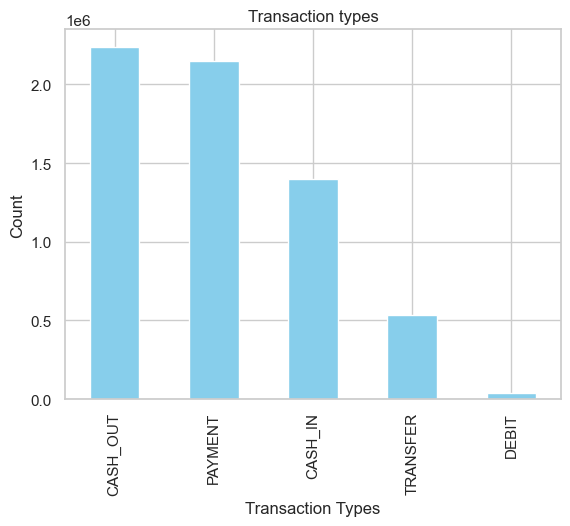

In [36]:
#visualizations

df['type'].value_counts().plot(kind='bar', title='Transaction types', color = 'skyblue')
plt.xlabel("Transaction Types")
plt.ylabel('Count')
plt.show()

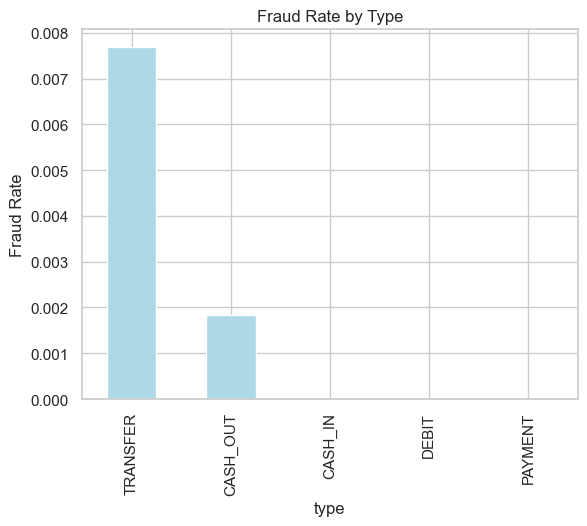

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [49]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind = 'bar', title = "Fraud Rate by Type", color = 'lightblue')
plt.ylabel('Fraud Rate')
plt.show()

fraud_by_type

In [50]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

In [53]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

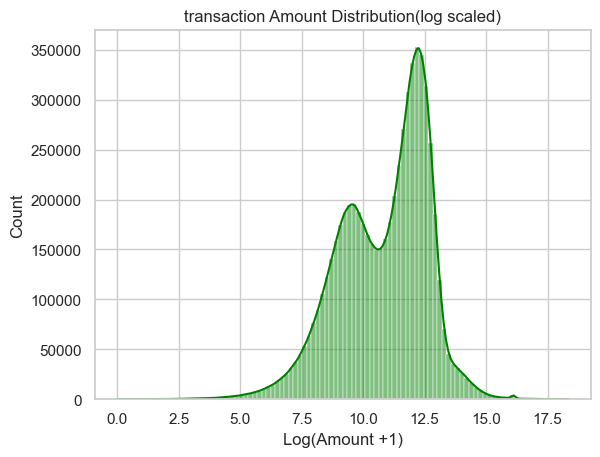

In [55]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde = True, color = 'green')
plt.title('transaction Amount Distribution(log scaled)')
plt.xlabel("Log(Amount +1)")
plt.show()

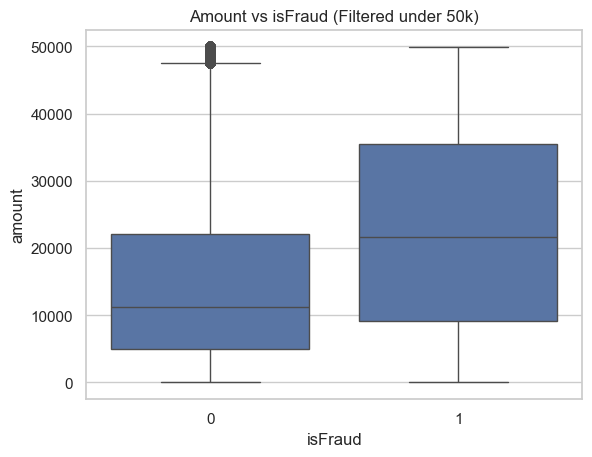

In [57]:
#relationship between fraud and amount
sns.boxplot(data=df[df['amount']<50000], x="isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [68]:
#checking if there are any negatives
df["balancedifforig"] = df["oldbalanceOrg"] - df['newbalanceOrig']
df['balancediffdest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [69]:
print((df['balancedifforig'] < 0).sum())

1399253


In [70]:
print((df['balancediffdest'] < 0).sum())

1238864


In [71]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancedifforig,balanccediffdest,balancediffdest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.0


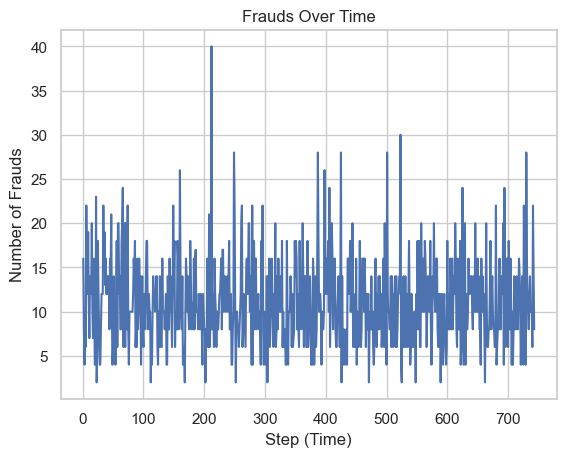

In [72]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label = "Frauds per step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title('Frauds Over Time')
plt.grid(True)
plt.show()

In [73]:
df.drop(columns = 'step', inplace = True)

In [74]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancedifforig,balanccediffdest,balancediffdest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0.0


In [76]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [78]:
top_receivers = df['nameDest'].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [80]:
fraud_users = df[df["isFraud"]==1]['nameOrig'].value_counts().head(10)
fraud_users

nameOrig
C1280323807    1
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C1039979813    1
C2089752665    1
C1614818636    1
C40604503      1
C1970706589    1
Name: count, dtype: int64

In [81]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancedifforig,balanccediffdest,balancediffdest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,21182.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,-46430.44,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,22425.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,-2712905.89,2712905.89


In [82]:
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

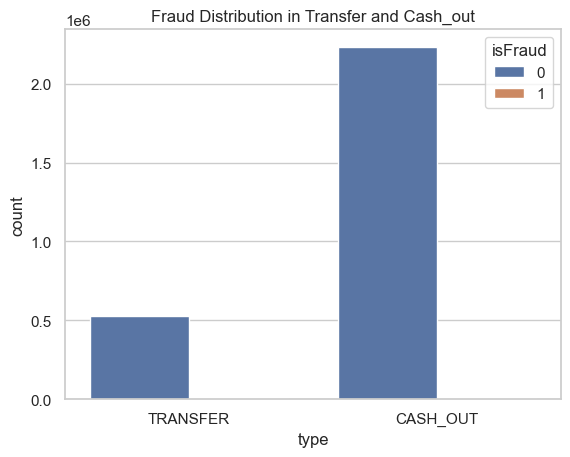

In [83]:
sns.countplot(data=fraud_types, x='type', hue = "isFraud")
plt.title("Fraud Distribution in Transfer and Cash_out")
plt.show()

In [87]:
corr = df[['amount',"oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


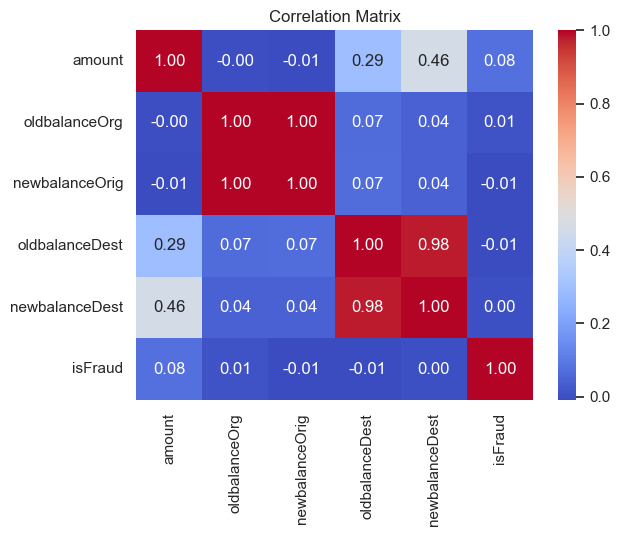

In [92]:
sns.heatmap(corr, annot=True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

In [95]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
   ( df["type"].isin(['TRANSFER', 'CASH_OUT']))
]

zero_after_transfer

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancedifforig,balanccediffdest,balancediffdest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,21182.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,-46430.44,46430.44
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,22425.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,-2712905.89,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,-339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,-6311409.27,6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00,0.00


In [96]:
len(zero_after_transfer)

1188074

In [97]:
#handling the imbalance
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix  #model evaluation
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer #data transformation
from sklearn.preprocessing import OneHotEncoder #data tranformations

In [ ]:
df_model = df.drop(["nameOrig", 'nameDest', 'isFlaggedFraud'], axis = 1)

In [101]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balancedifforig,balanccediffdest,balancediffdest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,21182.0,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,0.0


In [102]:
categorical = ['type']
numeric = ['amount', 'oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [104]:
y = df_model['isFraud']
X = df_model.drop('isFraud', axis = 1)

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, stratify = y)
#X_train and y_train holds 70% of the data and x_test and y_test holds 30% of the data

In [109]:
#preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop='first'), categorical)
    ],
    remainder='drop'
)

In [111]:
# model pipeline

pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [112]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [114]:
y_pred = pipeline.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [117]:
confusion_matrix(y_test, y_pred)

array([[1803875,  102447],
       [    154,    2310]])

In [ ]:
pipeline.score(X_test, y_test) #accuracy

0.9462480340907781

In [120]:
import joblib

In [121]:
joblib.dump(pipeline, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']